# Visits to American National Parks: Mini-Project Draft

**SI 699 mini project**

This notebook answers the mini-project prompts directly, in order: claim,
analysis, elaboration, discussion. The exploratory work it rests on lives in
[`sikandar_eda.ipynb`](sikandar_eda.ipynb) — data and methodology, Finding 1 (de-seasonalization),
Finding 2 (declining overnight camping), supporting context and limitations.

**Data source:** NPS Visitor Use Statistics, by-month extract, distributed via
[Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/)
(Walsh et al.). See the accompanying [data essay](https://www.responsible-datasets-in-context.com/posts/np-data/?tab=data-essay)
for collection methodology and known caveats.

## Setup

The cell below rebuilds the series this notebook refers to. They are the same
objects the EDA notebook computes in Finding 1 and Finding 2, using the same
helpers in `src/npdata.py`, so nothing here is a new or different estimate.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import npdata
import npviz

npviz.apply_style()
pd.set_option("display.max_columns", 50)

df = npdata.load_by_month()

# Finding 1: national June-August share, its trend, and the per-park version
national_matrix = npdata.monthly_matrix(df, ["Year"])
summer = npdata.summer_share(national_matrix)
fit = npdata.trend(summer)
years = summer.index.to_numpy(dtype=float)
pred = fit.slope / 10 * (years - years.mean()) + summer.mean()

park_year_matrix = npdata.monthly_matrix(df, ["ParkName", "Year"])
park_share = npdata.summer_share(park_year_matrix).dropna()
per_park = npdata.park_trends(park_share)

# the four robustness specifications fitted under Finding 1
checks = {
    "Main (visit-weighted national share)": fit,
    "Unweighted mean across the 63 parks": npdata.trend(park_share.groupby(level="Year").mean()),
    "Excluding 2020-2021": npdata.trend(summer.drop(index=[2020, 2021])),
    "Park-specific best 3 consecutive months": npdata.trend(npdata.peak3_share(national_matrix)),
}

# Finding 2: overnight stays per 1,000 recreation visits, and their log trends
annual = df.groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers", "Backcountry"]].sum()
per_1000 = annual[["TentCampers", "RVCampers", "Backcountry"]].div(annual["RecreationVisits"], axis=0) * 1000
camp_fits = {c: npdata.trend(per_1000[c], log=True) for c in per_1000.columns}

print(f"{df.shape[0]:,} rows · {df.ParkName.nunique()} parks · {df.Year.min()}–{df.Year.max()}")
print(f"summer share {fit.slope * 100:+.2f} pp/decade · "
      f"tent {camp_fits['TentCampers'].slope:+.1f}%/decade · "
      f"RV {camp_fits['RVCampers'].slope:+.1f}%/decade")


33,395 rows · 63 parks · 1979–2023
summer share -1.63 pp/decade · tent -14.3%/decade · RV -24.0%/decade


This section answers the mini-project prompts directly, in order. It draws
on the analysis above in [Finding 1](sikandar_eda.ipynb), [Finding 2](sikandar_eda.ipynb),
[Supporting context](sikandar_eda.ipynb) and [Limitations](sikandar_eda.ipynb),
and adds further analysis where the prompts call for depth the earlier
sections do not reach.

### Claim

Americans have not stopped visiting national parks in summer. They have
added visits everywhere else. Between 1979 and 2023 the June to August share
of visits fell about 1.6 percentage points per decade even though summer
visitation itself *grew* 29%, while front-country overnight stays fell from
about 118 to 60 per 1,000 visits. The typical park visit has steadily become
a shoulder-season day trip rather than a summer camping trip.

### Analysis

Both halves of the claim are trend estimates rather than before-and-after
comparisons. A single pair of endpoints, such as 1979 against 2023, would be
sensitive to whatever those two particular years happened to look like. For
each year we compute two things: the national share of recreation visits
falling in June to August, and campers per 1,000 recreation visits. We then
fit an ordinary-least-squares trend of each measure on year, using
Newey-West (HAC) standard errors, which allow for the serial correlation
that adjacent years of the same series obviously have (`npdata.trend`).
Camping rates are modelled in logs so the slope reads as a percent change
per decade, which suits a strictly positive rate that changes
multiplicatively.

The first figure puts both fitted trends side by side. It reuses the exact
series and fits computed in Finding 1 (`summer`, `fit`) and Finding 2
(`per_1000`, `camp_fits`) rather than recomputing anything:


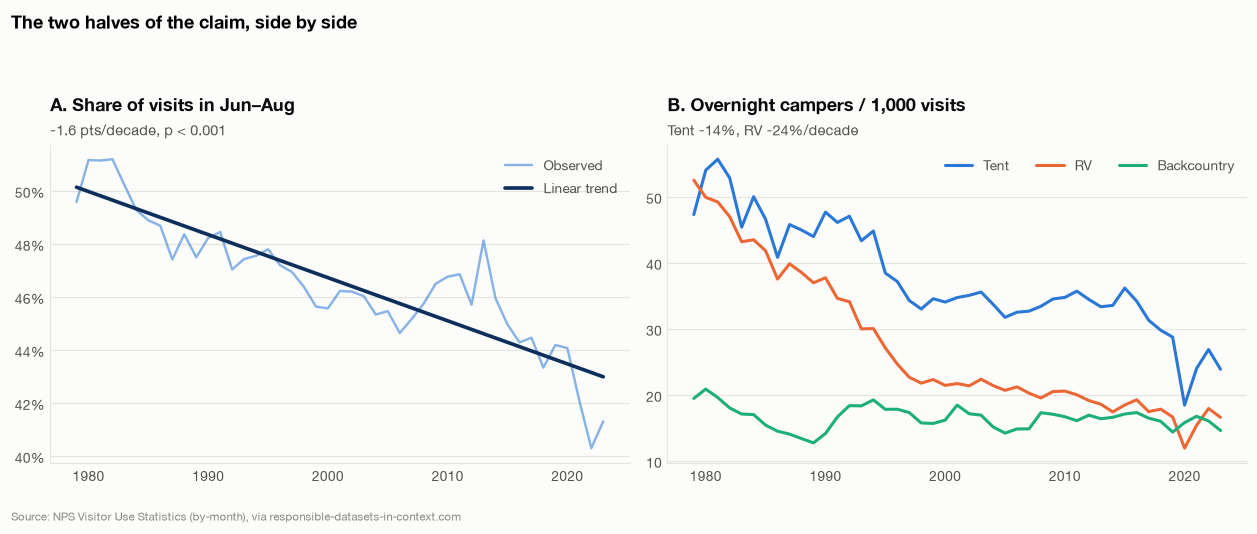

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# Panel A: national summer-visit share and its trend (Finding 1)
ax = axes[0]
ax.plot(summer.index, summer.values, color=npviz.BLUE, lw=1.6, alpha=0.55, label="Observed")
ax.plot(years, pred, color=npviz.DARK_BLUE, lw=2.4, label="Linear trend")
npviz.pct_axis(ax)
npviz.title(ax, "A. Share of visits in Jun–Aug",
            f"{fit.slope * 100:+.1f} pts/decade, p < 0.001")
ax.legend(loc="upper right")

# Panel B: overnight-camping rate and its trend (Finding 2)
ax = axes[1]
series_colors = {"TentCampers": npviz.BLUE, "RVCampers": npviz.ORANGE, "Backcountry": npviz.AQUA}
labels = {"TentCampers": "Tent", "RVCampers": "RV", "Backcountry": "Backcountry"}
for col, color in series_colors.items():
    ax.plot(per_1000.index, per_1000[col], color=color, lw=2, label=labels[col])
npviz.title(ax, "B. Overnight campers / 1,000 visits",
            f"Tent {camp_fits['TentCampers'].slope:+.0f}%, "
            f"RV {camp_fits['RVCampers'].slope:+.0f}%/decade")
ax.legend(loc="upper right", ncols=3)

fig.suptitle("The two halves of the claim, side by side",
             fontsize=12, fontweight="bold", x=0.01, ha="left", y=1.06)
npviz.source_note(fig)
npviz.save(fig, "07_claim_summary_panels")
plt.tight_layout()
plt.show()


Panel A establishes that the summer share is falling, and Panel B that the
camping rate is falling faster still. Neither panel on its own says *what
moved*, and that turns out to matter for how the claim should be worded. The
next three steps take each half of the claim apart.

**Which months actually changed?** "Summer share fell" is a statement about
one three-month block. Fitting the same trend to all twelve months
separately shows where the share went instead, and whether the movement is
concentrated or spread:


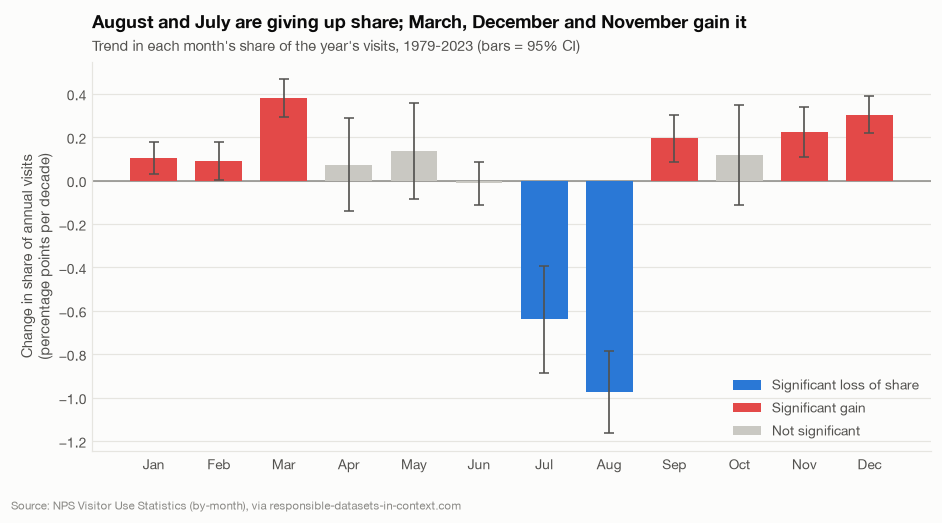

,slope,ci_low,ci_high,p_value
Jan,0.105,0.030,0.179,0.006
Feb,0.091,0.004,0.179,0.040
Mar,0.380,0.293,0.466,0.000
Apr,0.073,-0.141,0.287,0.506
May,0.137,-0.083,0.357,0.222
Jun,-0.012,-0.110,0.087,0.819
Jul,-0.639,-0.885,-0.392,0.000
Aug,-0.975,-1.164,-0.786,0.000
Sep,0.196,0.087,0.304,0.000
Oct,0.116,-0.114,0.346,0.325


In [3]:
from matplotlib.patches import Patch

month_share = national_matrix.div(national_matrix.sum(axis=1), axis=0)
month_fits = pd.DataFrame({m: npdata.trend(month_share[m]) for m in range(1, 13)}).T
for col in ["slope", "ci_low", "ci_high"]:
    month_fits[col] *= 100          # fractions -> percentage points
month_fits["significant"] = month_fits.p_value < 0.05

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = npviz.new_figure(8.6, 4.5)
bar_colors = [npviz.RED if (s and v > 0) else (npviz.BLUE if s else npviz.EMPHASIS_GRAY)
              for s, v in zip(month_fits.significant, month_fits.slope)]
ax.bar(range(12), month_fits.slope, color=bar_colors, width=0.72, zorder=3)
ax.errorbar(range(12), month_fits.slope,
            yerr=[month_fits.slope - month_fits.ci_low, month_fits.ci_high - month_fits.slope],
            fmt="none", ecolor=npviz.TEXT_SECONDARY, elinewidth=1.1, capsize=3, zorder=4)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1, zorder=2)
ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS)
ax.set_ylabel("Change in share of annual visits\n(percentage points per decade)")
ax.legend(handles=[Patch(facecolor=npviz.BLUE, label="Significant loss of share"),
                   Patch(facecolor=npviz.RED, label="Significant gain"),
                   Patch(facecolor=npviz.EMPHASIS_GRAY, label="Not significant")],
          loc="lower right")
npviz.title(ax, "August and July are giving up share; March, December and November gain it",
            "Trend in each month's share of the year's visits, 1979-2023 (bars = 95% CI)")
npviz.source_note(fig)
npviz.save(fig, "10_month_share_trends")
plt.tight_layout()
plt.show()

month_fits[["slope", "ci_low", "ci_high", "p_value"]].set_axis(MONTHS).round(3)


This is more specific than "summer is declining." The losses are
concentrated in the two deep-summer months, August at −0.98 points per
decade and July at −0.64, while June is flat and statistically
indistinguishable from no change. The offsetting gains are spread thinly
across the cold and shoulder months. The single biggest winner is **March**
at +0.38 points per decade, ahead of December (+0.30), November (+0.22) and
September (+0.20). By construction the twelve slopes sum to zero, so this is
a redistribution of a fixed 100%, not growth or decline in itself.

That March leads is a useful corrective to the intuitive story. A pure
"climate lengthens the hiking season" account would predict gains landing
symmetrically in May and June, then September and October. Instead the
largest gain sits in early spring, which is when desert parks peak and when
school spring break falls. That fits *which parks and trips people choose*
much better than it fits warmer shoulder weather alone.

**Is summer actually shrinking?** A falling share is compatible with two
very different worlds: summer visitation declining, or summer growing more
slowly than everything else. These have opposite implications for crowding
and staffing, so the distinction matters. Comparing absolute visit counts
separates them:


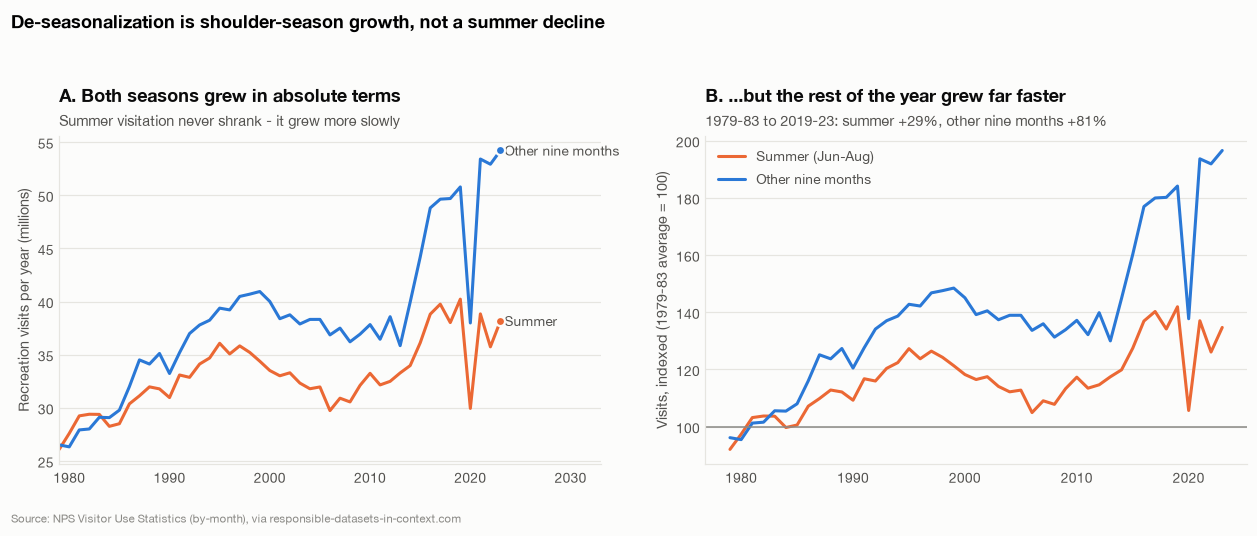

In [4]:
is_summer = df.Month.isin(npdata.SUMMER)
abs_year = pd.DataFrame({
    "Summer (Jun-Aug)": df[is_summer].groupby("Year").RecreationVisits.sum(),
    "Other nine months": df[~is_summer].groupby("Year").RecreationVisits.sum()})
growth = (abs_year.loc[2019:2023].mean() / abs_year.loc[1979:1983].mean() - 1) * 100
indexed = abs_year.div(abs_year.loc[1979:1983].mean()) * 100

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax = axes[0]
for col, color in zip(abs_year.columns, [npviz.ORANGE, npviz.BLUE]):
    ax.plot(abs_year.index, abs_year[col] / 1e6, color=color, lw=2)
    npviz.end_label(ax, abs_year.index[-1], abs_year[col].iloc[-1] / 1e6, col.split(" (")[0], color=color)
ax.set_xlim(1979, 2033)
ax.set_ylabel("Recreation visits per year (millions)")
npviz.title(ax, "A. Both seasons grew in absolute terms",
            "Summer visitation never shrank - it grew more slowly")

ax = axes[1]
for col, color in zip(indexed.columns, [npviz.ORANGE, npviz.BLUE]):
    ax.plot(indexed.index, indexed[col], color=color, lw=2, label=col)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1)
ax.set_ylabel("Visits, indexed (1979-83 average = 100)")
ax.legend(loc="upper left")
npviz.title(ax, "B. ...but the rest of the year grew far faster",
            f"1979-83 to 2019-23: summer {growth.iloc[0]:+.0f}%, other nine months {growth.iloc[1]:+.0f}%")

fig.suptitle("De-seasonalization is shoulder-season growth, not a summer decline",
             fontsize=12, fontweight="bold", x=0.01, ha="left", y=1.04)
npviz.source_note(fig)
npviz.save(fig, "11_absolute_season_growth")
plt.tight_layout()
plt.show()


Summer visitation grew 29% between the first and last five years of the
panel. The other nine months grew 81%, nearly three times faster. So the
falling summer share reflects the rest of the calendar filling in, not
summer emptying out. The claim is about *redistribution*, and any wording
implying parks are quieter in August than they used to be would be wrong.
In absolute terms August is busier than ever. It simply no longer dominates
the year the way it did.

**Is the camping decline just a denominator effect?** A rate can fall
because its numerator shrinks or because its denominator grows. Since total
visits rose 55% over the same period, a falling camping *rate* could in
principle coexist with rising camping. Plotting the numerator directly
settles it:


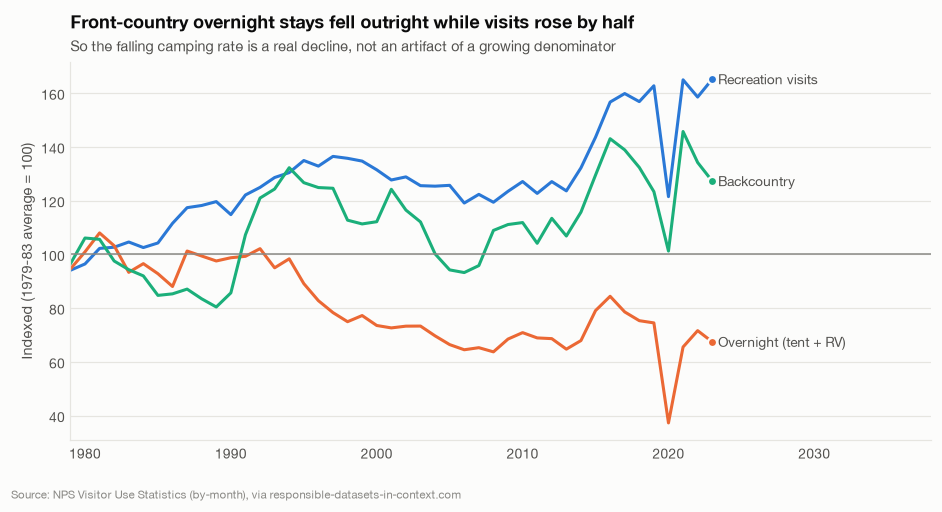

,"% change, 1979-83 to 2019-23"
Recreation visits,54.6
Overnight (tent + RV),-36.7
Backcountry,26.4


In [5]:
annual_tot = df.groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers", "Backcountry"]].sum()
annual_tot["Overnight (tent + RV)"] = annual_tot.TentCampers + annual_tot.RVCampers
absolute = annual_tot[["RecreationVisits", "Overnight (tent + RV)", "Backcountry"]].rename(
    columns={"RecreationVisits": "Recreation visits"})
abs_change = (absolute.loc[2019:2023].mean() / absolute.loc[1979:1983].mean() - 1) * 100
abs_indexed = absolute.div(absolute.loc[1979:1983].mean()) * 100

fig, ax = npviz.new_figure(8.6, 4.4)
for col, color in zip(abs_indexed.columns, [npviz.BLUE, npviz.ORANGE, npviz.AQUA]):
    ax.plot(abs_indexed.index, abs_indexed[col], color=color, lw=2)
    npviz.end_label(ax, abs_indexed.index[-1], abs_indexed[col].iloc[-1], col, color=color)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1)
ax.set_xlim(1979, 2038)
ax.set_ylabel("Indexed (1979-83 average = 100)")
npviz.title(ax, "Front-country overnight stays fell outright while visits rose by half",
            "So the falling camping rate is a real decline, not an artifact of a growing denominator")
npviz.source_note(fig)
npviz.save(fig, "12_absolute_overnight")
plt.tight_layout()
plt.show()

abs_change.round(1).rename("% change, 1979-83 to 2019-23").to_frame()


Front-country overnight stays fell 37% in absolute terms while recreation
visits rose 55%. The falling rate is therefore driven by the numerator, and
the denominator effect works *against* the finding rather than creating it.
Backcountry stays are the exception. They rose 26% absolutely, roughly in
line with a growing visitor base, which is why the backcountry rate shows no
significant trend. The decline is specific to developed campgrounds, not to
sleeping outdoors in general.

**A formal within-park test.** Finding 2's shift-share decomposition
attributes the aggregate move to within-park change, but it compares two
period averages and says nothing about the years between. A panel regression
with park fixed effects is the stronger version of the same test. Every
time-invariant difference between parks is absorbed, including size,
climate, road access and whether the park has campgrounds at all. The year
coefficient is then identified purely from change *inside* parks over time,
with standard errors clustered by park (`npdata.panel_trend`):


In [6]:
# Summer share: within-park trend (fractions -> percentage points)
fe_season = npdata.panel_trend(park_share)

# Camping rate per park-year: within-park trend on the log rate (-> % per decade)
park_year = df.groupby(["ParkName", "Year"])[["RecreationVisits", "TentCampers", "RVCampers"]].sum()
park_year = park_year[park_year.RecreationVisits > 0]
camp_rate_py = ((park_year.TentCampers + park_year.RVCampers) / park_year.RecreationVisits * 1000)
camp_rate_py = camp_rate_py.replace(0, np.nan).dropna()
fe_camp = npdata.panel_trend(camp_rate_py, log=True)

fe_table = pd.DataFrame(
    {"estimate": [fe_season.slope * 100, fe_camp.slope],
     "ci_low": [fe_season.ci_low * 100, fe_camp.ci_low],
     "ci_high": [fe_season.ci_high * 100, fe_camp.ci_high],
     "p_value": [fe_season.p_value, fe_camp.p_value],
     "park_years": [fe_season.n_obs, fe_camp.n_obs],
     "parks": [fe_season.n_units, fe_camp.n_units]},
    index=["Summer share (pp/decade)", "Camping rate (%/decade)"])
fe_table.round(3)


,estimate,ci_low,ci_high,p_value,park_years,parks
Summer share (pp/decade),-0.925,-1.584,-0.266,0.006,2779.0,63.0
Camping rate (%/decade),-18.950,-25.110,-12.285,0.000,2036.0,51.0


Both findings survive the stricter test. Within the average park the summer
share falls 0.93 points per decade (95% CI −1.58 to −0.27, *p* = 0.006,
2,779 park-years), and the camping rate falls 19.0% per decade (95% CI
−25.1 to −12.3, *p* < 0.001, 2,036 park-years across the 51 parks that
record any camping). Neither finding is an artifact of *which* parks people
visit.

Two details are worth flagging honestly. First, the within-park summer-share
estimate of −0.93 is noticeably smaller than the national visit-weighted
estimate of −1.62, and close to the unweighted park average. The aggregate
number is amplified by the largest parks de-seasonalizing faster than the
typical park. Both are true. The national figure describes the visiting
public's experience, the within-park figure describes the average park, and
the claim above quotes the national one. Second, the camping panel drops 12
parks with no recorded camping, so that estimate speaks to parks that have
campgrounds rather than to the system as a whole.


### Elaboration

A claim earns confidence by surviving reasonable changes to how it is
measured, and by varying across time and place in ways that make sense
rather than arbitrarily. This section works through four questions: whether
the specification drives the result, whether it holds everywhere, whether
the two halves of the claim are really one phenomenon, and whether the pace
has been constant.

**1. Does the specification drive the result?** Finding 1's robustness table
refits the summer-share trend four ways: visit-weighted nationally, as an
unweighted mean across parks, excluding the COVID-affected 2020 and 2021
years, and using each park's own best three consecutive months instead of a
fixed calendar summer. Two more are added here. The first is the within-park
fixed-effects estimate from the section above. The second is a balanced
panel that keeps only the 55 parks observed across the entire window, since
8 parks enter the file late and could otherwise change the national mix over
time.


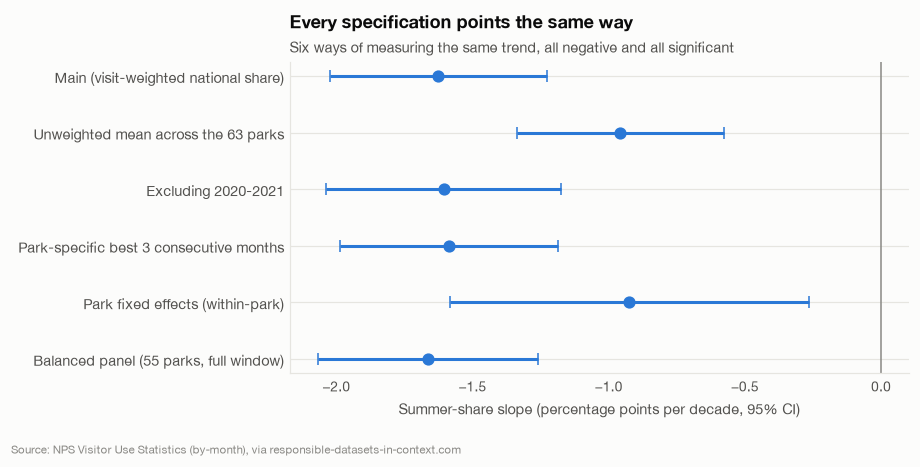

,slope,ci_low,ci_high,p_value
Main (visit-weighted national share),-1.625,-2.024,-1.226,0.000
Unweighted mean across the 63 parks,-0.958,-1.338,-0.578,0.000
Excluding 2020-2021,-1.605,-2.036,-1.174,0.000
Park-specific best 3 consecutive months,-1.586,-1.988,-1.185,0.000
Park fixed effects (within-park),-0.925,-1.584,-0.266,0.006
"Balanced panel (55 parks, full window)",-1.664,-2.068,-1.260,0.000


In [7]:
specs = dict(checks)          # the four specifications fitted under Finding 1

# (e) within-park estimate from the fixed-effects panel above
specs["Park fixed effects (within-park)"] = fe_season

# (f) balanced panel: only parks observed across the whole 1979-2023 window,
#     since 8 parks enter the file late (Alaska parks 1982, Congaree 1985,
#     American Samoa 2002) and could otherwise shift the national mix over time
span = df.groupby("ParkName").Year.agg(["min", "max"])
balanced_parks = span[(span["min"] <= 1979) & (span["max"] >= 2023)].index
specs[f"Balanced panel ({len(balanced_parks)} parks, full window)"] = npdata.trend(
    npdata.summer_share(npdata.monthly_matrix(df[df.ParkName.isin(balanced_parks)], ["Year"])))

fig, ax = npviz.new_figure(8.4, 4.0)
names = list(specs.keys())
est = [specs[k].slope * 100 for k in names]
lo = [(specs[k].slope - specs[k].ci_low) * 100 for k in names]
hi = [(specs[k].ci_high - specs[k].slope) * 100 for k in names]

ax.errorbar(est, range(len(names)), xerr=[lo, hi], fmt="o", color=npviz.BLUE,
            ecolor=npviz.BLUE, elinewidth=2, capsize=4, markersize=7, zorder=3)
ax.axvline(0, color=npviz.TEXT_MUTED, lw=1, zorder=1)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel("Summer-share slope (percentage points per decade, 95% CI)")
npviz.title(ax, "Every specification points the same way",
            "Six ways of measuring the same trend, all negative and all significant")
npviz.source_note(fig)
npviz.save(fig, "08_robustness_forest_plot")
plt.tight_layout()
plt.show()

pd.DataFrame({k: specs[k][["slope", "ci_low", "ci_high", "p_value"]] * [100, 100, 100, 1]
              for k in names}).T.round(3)


All six intervals sit entirely below zero. The estimates fall into two
groups, and they differ for an interpretable reason rather than a worrying
one. The three visit-weighted national specifications cluster near −1.6
points per decade. The two that give every park equal weight, the unweighted
mean and the fixed-effects panel, sit nearer −0.9, because the largest parks
are de-seasonalizing faster than the median park. The balanced panel at
−1.66 is indistinguishable from the full panel at −1.62, so the
late-entering parks, 1.8% of all recorded visits, are not driving anything.

**2. Does it hold everywhere?** The national figure could mask a pattern
driven by one part of the country. Fitting the same trend within each NPS
region tests that directly:


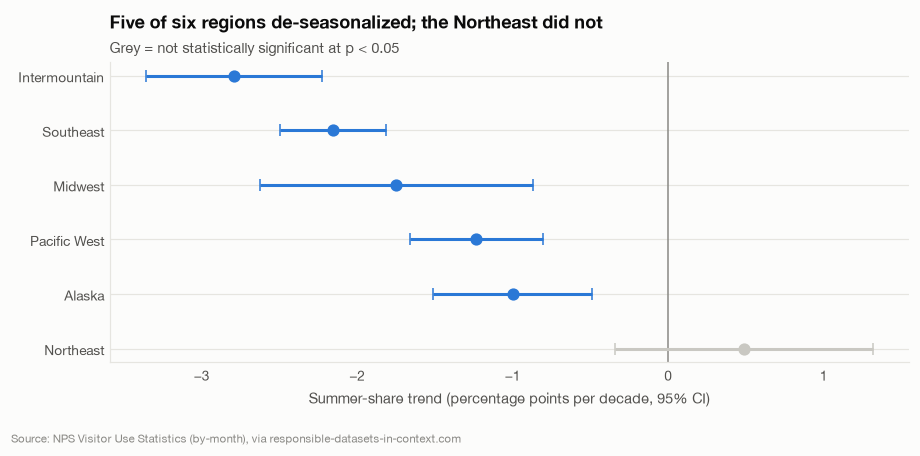

,slope,ci_low,ci_high,p_value
Intermountain,-2.792,-3.359,-2.225,0.000
Southeast,-2.156,-2.494,-1.818,0.000
Midwest,-1.749,-2.627,-0.871,0.000
Pacific West,-1.236,-1.664,-0.809,0.000
Alaska,-1.000,-1.512,-0.488,0.000
Northeast,0.487,-0.342,1.316,0.249


In [8]:
region_share = npdata.summer_share(npdata.monthly_matrix(df, ["Region", "Year"])).dropna()
region_fits = pd.DataFrame({r: npdata.trend(s.droplevel(0))
                            for r, s in region_share.groupby(level=0)}).T
for col in ["slope", "ci_low", "ci_high"]:
    region_fits[col] *= 100
region_fits = region_fits.sort_values("slope")

fig, ax = npviz.new_figure(8.4, 3.9)
region_colors = [npviz.BLUE if p < 0.05 else npviz.EMPHASIS_GRAY for p in region_fits.p_value]
for i, (row, color) in enumerate(zip(region_fits.itertuples(), region_colors)):
    ax.errorbar(row.slope, i, xerr=[[row.slope - row.ci_low], [row.ci_high - row.slope]],
                fmt="o", color=color, ecolor=color, elinewidth=2, capsize=4, markersize=7, zorder=3)
ax.axvline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_yticks(range(len(region_fits)))
ax.set_yticklabels(region_fits.index)
ax.invert_yaxis()
ax.set_xlabel("Summer-share trend (percentage points per decade, 95% CI)")
npviz.title(ax, "Five of six regions de-seasonalized; the Northeast did not",
            "Grey = not statistically significant at p < 0.05")
npviz.source_note(fig)
npviz.save(fig, "13_regional_trends")
plt.tight_layout()
plt.show()

region_fits[["slope", "ci_low", "ci_high", "p_value"]].round(3)


Five of six regions de-seasonalized significantly, but the size of the
effect varies more than threefold. It runs from −2.79 points per decade in
the Intermountain region, the Utah and Colorado desert and canyon parks,
down to −1.00 in Alaska. The **Northeast is the exception**. Its estimate is
slightly *positive* at +0.49 and not significant, so we cannot say it
de-seasonalized at all.

That ordering is informative rather than random. The regions with the most
room to spread visits into a mild off-season moved most. The Northeast
barely moved, and it is also where winter genuinely closes much of the
visitor infrastructure and where Acadia's season is weather-bound. This is a
real limit on the claim's scope. It describes national and especially
Western visitation, not every part of the park system equally.

**3. Are the two halves of the claim one phenomenon or two?** The claim
bundles de-seasonalization and declining overnight stays into a single
sentence about shorter, off-peak trips. If they were one underlying shift,
parks that de-seasonalized most should also have shed camping fastest. That
is worth testing rather than assuming. We test it alongside a second check,
that the trend is not simply a ceiling effect in which the parks starting
most summer-concentrated had the most room to fall:


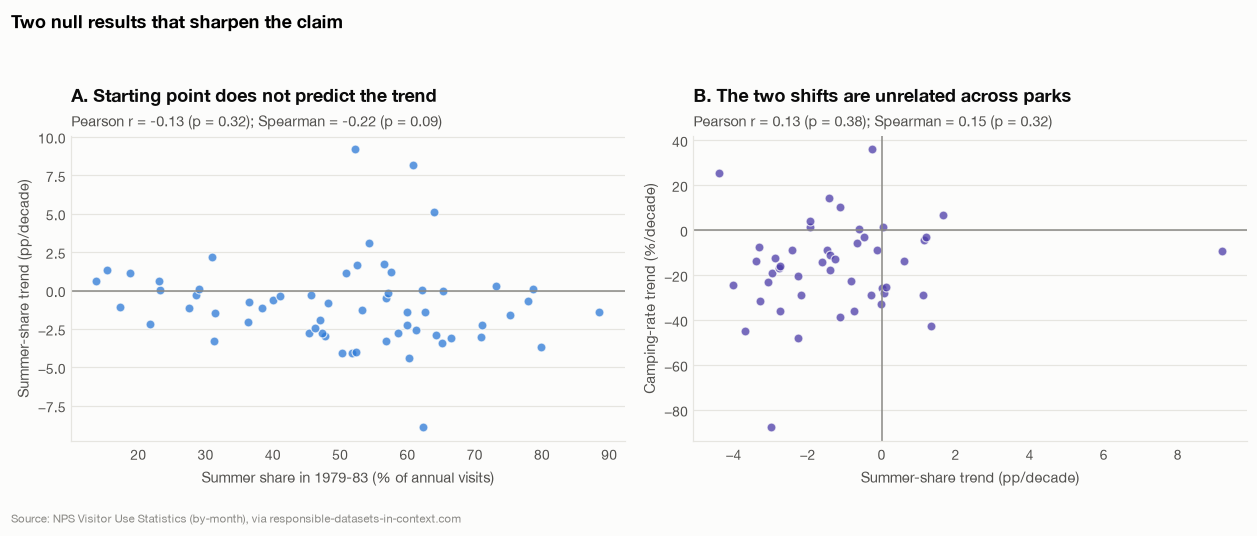

n = 60 parks (panel A), 47 parks (panel B)


In [9]:
from scipy import stats

# (a) does a park's starting summer share predict how fast it de-seasonalized?
baseline = (park_share[park_share.index.get_level_values("Year").isin(range(1979, 1984))]
            .groupby(level=0).mean())
base_vs_trend = per_park.join(baseline.rename("baseline")).dropna(subset=["baseline"])
r_base, p_base = stats.pearsonr(base_vs_trend.baseline * 100, base_vs_trend.slope * 100)
rho_base, prho_base = stats.spearmanr(base_vs_trend.baseline, base_vs_trend.slope)

# (b) do parks that de-seasonalized also lose camping fastest?
camp_park_trends = {}
for park, s in camp_rate_py.groupby(level=0):
    s = s.droplevel(0).dropna()
    if len(s) >= 20:
        camp_park_trends[park] = npdata.trend(s, log=True)
camp_park_trends = pd.DataFrame(camp_park_trends).T

paired = (per_park[["slope"]].rename(columns={"slope": "season_trend"})
          .join(camp_park_trends[["slope"]].rename(columns={"slope": "camp_trend"}), how="inner")
          .dropna())
paired["season_trend"] *= 100
r_pair, p_pair = stats.pearsonr(paired.season_trend, paired.camp_trend)
rho_pair, prho_pair = stats.spearmanr(paired.season_trend, paired.camp_trend)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax = axes[0]
ax.scatter(base_vs_trend.baseline * 100, base_vs_trend.slope * 100, color=npviz.BLUE,
           s=34, alpha=0.75, edgecolor=npviz.SURFACE, linewidth=0.8)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xlabel("Summer share in 1979-83 (% of annual visits)")
ax.set_ylabel("Summer-share trend (pp/decade)")
npviz.title(ax, "A. Starting point does not predict the trend",
            f"Pearson r = {r_base:.2f} (p = {p_base:.2f}); Spearman = {rho_base:.2f} (p = {prho_base:.2f})")

ax = axes[1]
ax.scatter(paired.season_trend, paired.camp_trend, color=npviz.VIOLET,
           s=34, alpha=0.75, edgecolor=npviz.SURFACE, linewidth=0.8)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.axvline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xlabel("Summer-share trend (pp/decade)")
ax.set_ylabel("Camping-rate trend (%/decade)")
npviz.title(ax, "B. The two shifts are unrelated across parks",
            f"Pearson r = {r_pair:.2f} (p = {p_pair:.2f}); Spearman = {rho_pair:.2f} (p = {prho_pair:.2f})")

fig.suptitle("Two null results that sharpen the claim",
             fontsize=12, fontweight="bold", x=0.01, ha="left", y=1.04)
npviz.source_note(fig)
npviz.save(fig, "14_two_null_results")
plt.tight_layout()
plt.show()

print(f"n = {len(base_vs_trend)} parks (panel A), {len(paired)} parks (panel B)")


Both tests come back null, and both nulls are useful.

Panel A: a park's summer concentration in 1979 to 1983 does not predict how
fast it later de-seasonalized (*r* = −0.13, *p* = 0.32; Spearman −0.22,
*p* = 0.09). Parks that began at 80% summer were no more likely to fall than
parks that began at 40%. That is what we would want to see before ruling out
a mechanical ceiling effect, or regression to the mean, as the explanation.

Panel B is the more interesting result, because it *complicates* the claim.
Across the 47 parks where both trends can be estimated, the summer-share
trend and the camping-rate trend are essentially uncorrelated (*r* = 0.13,
*p* = 0.38; Spearman 0.15, *p* = 0.32). A park that spread its visits across
the year was no more likely to lose campers than one that did not. So the
two halves of the claim are two distinct shifts happening over the same
period, not a single "shorter trips" factor showing up in two measures. The
claim is still accurate as a description of how the average visit changed,
but it should not be read as identifying one cause. The wording above
deliberately says the visit "has become" a shoulder-season day trip rather
than asserting that one mechanism produced both.

**4. Has the pace been constant?** The fitted slopes summarise 45 years in a
single line. Two sensitivity checks ask whether that line hides a changing
rate. The first is a rolling 20-year window, the second is the choice of
start year:


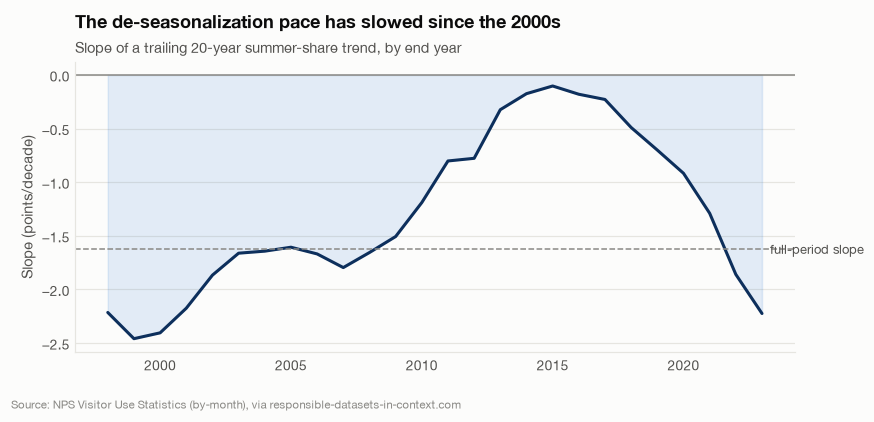

In [10]:
window = 20
rolling_slopes = {}
yrs = summer.index.to_numpy()
for end_year in range(yrs.min() + window - 1, yrs.max() + 1):
    win = summer[(summer.index > end_year - window) & (summer.index <= end_year)]
    if len(win) == window:
        rolling_slopes[end_year] = npdata.trend(win).slope * 100
rolling_slopes = pd.Series(rolling_slopes)

fig, ax = npviz.new_figure(8, 3.6)
ax.plot(rolling_slopes.index, rolling_slopes.values, color=npviz.DARK_BLUE, lw=2)
ax.fill_between(rolling_slopes.index, rolling_slopes.values, 0,
                 color=npviz.BLUE, alpha=0.12)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.axhline(fit.slope * 100, color=npviz.TEXT_MUTED, lw=1, ls="--")
ax.text(rolling_slopes.index.max(), fit.slope * 100, "  full-period slope",
        fontsize=8.5, color=npviz.TEXT_SECONDARY, va="center")
npviz.title(ax, "The de-seasonalization pace has slowed since the 2000s",
            "Slope of a trailing 20-year summer-share trend, by end year")
ax.set_ylabel("Slope (points/decade)")
npviz.source_note(fig)
npviz.save(fig, "09_rolling_trend_slope")
plt.tight_layout()
plt.show()


The rolling slope is negative in every 20-year window, so the direction
never reverses. Its magnitude is far from constant, though. It weakens from
the late 1990s toward roughly zero by the mid-2010s, then swings sharply
negative again in windows ending after 2020. That last swing should not be
read as a behavioural re-acceleration. Those windows all contain the
anomalous 2020 and 2021 closures, so part of it is mechanical. Setting the
pandemic windows aside, the honest summary is that de-seasonalization was
fastest in the 1980s and 1990s and slowest around 2010 to 2017.

The choice of start year is the other decision that could be doing work,
since the series begins in 1979 for reasons of data availability rather than
theory:


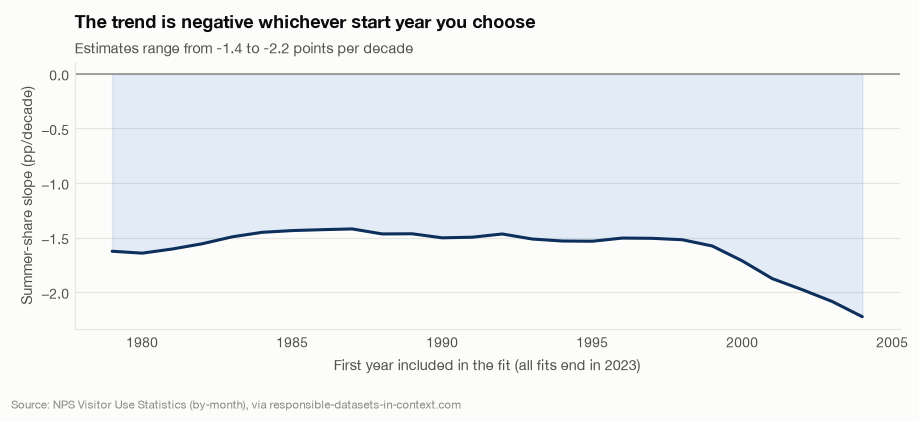

In [11]:
start_year_slopes = pd.Series({
    y0: npdata.trend(summer[summer.index >= y0]).slope * 100
    for y0 in range(1979, 2005)})

fig, ax = npviz.new_figure(8.4, 3.6)
ax.plot(start_year_slopes.index, start_year_slopes.values, color=npviz.DARK_BLUE, lw=2)
ax.fill_between(start_year_slopes.index, start_year_slopes.values, 0,
                color=npviz.BLUE, alpha=0.12)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xlabel("First year included in the fit (all fits end in 2023)")
ax.set_ylabel("Summer-share slope (pp/decade)")
npviz.title(ax, "The trend is negative whichever start year you choose",
            f"Estimates range from {start_year_slopes.max():.1f} to "
            f"{start_year_slopes.min():.1f} points per decade")
npviz.source_note(fig)
npviz.save(fig, "15_start_year_sensitivity")
plt.tight_layout()
plt.show()


Every start year from 1979 to 2004 yields a negative slope, ranging from
−1.4 to −2.2 points per decade. The estimate is flat and near −1.5 for any
start in the 1980s or 1990s and becomes *more* negative for later starts,
because shorter recent windows weight the pandemic years more heavily. The
sign is therefore not a choice we made; the precise magnitude partly is, and
the claim quotes the full-window figure rather than the most dramatic one.

Finally, the [2020 regional-recovery analysis](sikandar_eda.ipynb) shows
the one large shock in the panel hitting regions unevenly, with different
recovery speeds through 2023. It is useful context for how volatile
year-to-year visitation is around these slow-moving trends, but as a single
event it is not treated as evidence for either half of the claim.

### Discussion

**What is genuinely surprising.** The headline number, a falling summer
share, sounds like a story about summer, and it is not. Summer visitation
grew 29% over the panel. It simply grew far more slowly than the other nine
months, which grew 81%. Reporting only the share would invite a reader to
conclude that August has quietened down, when August is in fact busier than
it has ever been. The second surprise is *which* months absorbed the shift.
A warming-climate account predicts symmetric gains in the shoulder months.
Instead March is the single biggest winner, ahead of December and November,
which points toward spring-break timing and the rise of desert and Sun-Belt
parks rather than a longer alpine hiking season. The third is the null in
Panel B above. De-seasonalization and the camping decline are uncorrelated
across parks, so what reads as one coherent lifestyle shift is better
described as two independent changes that happen to point the same direction
for the average visit.

**What is obvious but worth confirming.** That overall visitation grew, and
that summer still dominates, are both unremarkable. They matter as sanity
checks. Even after 45 years of de-seasonalization, roughly 44% of visits
still fall in three of twelve months, about 1.8 times what a flat calendar
would give. The system has become less seasonal, not unseasonal, and nothing
here suggests the peak is going away.

**What the analysis can and cannot say about mechanism.** The data support
the *description* strongly and the *explanation* weakly. We can rule out
several alternatives. The pattern is not an aggregation artifact, since it
holds within parks with fixed effects. It is not a composition effect from
parks entering the file late, since the balanced panel matches. It is not a
ceiling effect, since starting concentration does not predict the trend. It
is not a pandemic artifact, since it holds when 2020 and 2021 are excluded.
And the camping decline is not a denominator effect, since overnight stays
fell 37% in absolute terms. What we cannot do is identify a cause.
Campground capacity is essentially fixed while visits grew 55%, so some of
the camping decline could be rationing rather than changing preference, and
this dataset contains no capacity or reservation data with which to separate
the two. We also cannot distinguish warmer shoulder seasons from cheaper
off-peak travel, changing demographics, or timed-entry policies. All of
those would leave a similar footprint in monthly counts.

**What would change our mind.** The de-seasonalization claim would be in
trouble if campground or road-closure records showed that parks simply
opened for more of the year over this period, which would make the pattern a
supply artifact rather than a behavioural one. The same would apply if NPS
counting methodology changed in a way that improved off-season coverage
specifically, and the data essay's account of formula-based, park-specific
adjustments means we cannot fully exclude it. The camping claim would be in
trouble if campground capacity fell over the period, since a declining rate
would then be mostly mechanical. Both are checkable against records outside
this file, and both are listed as next steps.

**Generalizability.** We would extend these findings along some dimensions
and not others. *Across time:* the direction is the safer bet than the rate.
Both series are negative in every rolling window and under every start year,
but the pace varies by a factor of two and slowed markedly in the 2010s.
Extrapolating −1.6 points per decade far into the future would overstate the
change, and the honest forecast is continued but decelerating
de-seasonalization. *Across place:* not uniformly. The effect is three times
larger in the Intermountain region than in Alaska and is absent in the
Northeast, so this is primarily a statement about national and Western
visitation. *Across park types:* we would not extend it at all. The file
contains only the 63 units designated "National Park". Monuments,
seashores, recreation areas and historic sites are excluded and plausibly
behave differently, since many are already dominated by short local day
visits that leave little room for the same shift. *Across visitation
habits:* the findings describe *counted recreation visits*, which per the
data essay exclude commuters, researchers, staff and Indigenous residents of
park lands, and which under-represent communities with less access to parks
in the first place. The claim is about how counted visits are distributed
across the calendar. It should not be read as a claim about how all people
relate to these places.


## Potential topics for further exploration <a id='Further-topics'></a>

Beyond the primary claim above, the by-month panel supports several other
lines of analysis we did not pursue in depth here. They are listed roughly
in order of how promising they looked during EDA:

1. **Weekday, weekend and holiday timing.** This file is monthly, so it
   cannot speak to within-month timing. A day-level NPS dataset could test
   whether the de-seasonalization in Finding 1 is really "more
   shoulder-season trips" or "more long weekends", which have different
   implications for park staffing.
2. **Climate as a driver.** Overlaying regional temperature and
   precipitation anomalies, such as NOAA climate divisions, against each
   park's seasonality score could test whether the parks trending toward
   *more* summer concentration are responding to lengthening warm seasons
   rather than to growing tourism.
3. **Camping supply constraints.** Cross-referencing NPS campground
   capacity or reservation data, such as Recreation.gov bookings, against
   the `TentCampers` and `RVCampers` rate would separate a demand-side
   change from a supply-side ceiling. Right now we can only flag this as a
   limitation rather than resolve it.
4. **Fee and reservation-system changes.** Several high-traffic parks
   introduced timed-entry reservations around 2020 and 2021, including Zion
   and Glacier. A park-level event study around each policy's introduction
   date could test whether de-seasonalization is partly a policy effect
   rather than an organic behavior shift.
5. **NonRecreationVisits as a validity check.** We did not use this column.
   Comparing its trend to `RecreationVisits` could sanity-check whether
   counting methodology itself has drifted over the 45-year window, which is
   the measurement caveat raised in Limitations.
6. **Extending past 2023.** The data essay notes that 2024 annual figures
   were reportedly suppressed after release. If a by-month 2024 to 2025
   extract becomes available, re-running Finding 1's trend would test
   whether the de-seasonalization continued, plateaued or reversed after the
   pandemic.
